In [ ]:
#Author: Betül Balcı
#Date: December 2025

In [ ]:
#Real Estate Valuation Dataset

In [ ]:
#Firstly, we'll begin by analyzing the characteristics of our dataset.

In [ ]:
#This dataset was collected from a region in Taiwan (Sindian, New Taipei City).
#The main purpose of this dataset is to estimate the price per square meter of residential properties. 
#Several variables were used for this estimation.
#Regarding the independent variables in the dataset and the characteristics of the dependent variable we wish to estimate:

In [ ]:
#1.) No - Registration number (ID): This variable is used to assign a sequential number to each row.
# 2.) transaction date : This variable represents the transaction date in decimal year format.
# 3.) house age : This variable represents the house age in years when sold.
# 4.) Distance to the nearest MRT station: Indicates the distance to the nearest metro (MRT) station in meters.
# 5.) Number of convenience stores: This variable shows the number of convenience stores around the house.
# 6.) latitude : Indicates the latitude coordinate of the house's location.
# 7.) longitude : Indicates the longitude coordinate of the house's location. 
# 8.) house price per unit area (target variable): This variable indicates the sales price per unit area of the house.
# (Calculated in New Taiwan Dollars/ping, where 1 ping = 3.3 square meters.) 

In [ ]:
#We'll now begin our analysis of the dataset.

In [ ]:
#Firstly, let's load our dataset and import the required libraries.

In [370]:
import pandas as pd
import numpy as np

In [373]:
data = pd.read_csv("real_estate.csv")

In [374]:
data.head()

,No,transaction date,house age,distance to the nearest MRT station,number of convenience stores,latitude,longitude,house price of unit area
0,1,2012.917,32.0,84.87882,10,24.98298,121.54024,37.9
1,2,2012.917,19.5,306.59470,9,24.98034,121.53951,42.2
2,3,2013.583,13.3,561.98450,5,24.98746,121.54391,47.3
3,4,2013.500,13.3,561.98450,5,24.98746,121.54391,54.8
4,5,2012.833,5.0,390.56840,5,24.97937,121.54245,43.1


In [375]:
#Missing Value Check

In [376]:
data.isnull().values.any()

False

In [ ]:
#There are no missing values in the dataset

In [ ]:
#Descriptive Statistics of the Dataset 

In [377]:
data.describe().T

,count,mean,std,min,25%,50%,75%,max
No,414.0,207.500000,119.655756,1.00000,104.250000,207.50000,310.750000,414.00000
transaction date,414.0,2013.148971,0.281967,2012.66700,2012.917000,2013.16700,2013.417000,2013.58300
house age,414.0,17.712560,11.392485,0.00000,9.025000,16.10000,28.150000,43.80000
distance to the nearest MRT station,414.0,1083.885689,1262.109595,23.38284,289.324800,492.23130,1454.279000,6488.02100
number of convenience stores,414.0,4.094203,2.945562,0.00000,1.000000,4.00000,6.000000,10.00000
latitude,414.0,24.969030,0.012410,24.93207,24.963000,24.97110,24.977455,25.01459
longitude,414.0,121.533361,0.015347,121.47353,121.528085,121.53863,121.543305,121.56627
house price of unit area,414.0,37.980193,13.606488,7.60000,27.700000,38.45000,46.600000,117.50000


In [ ]:
#Let's remove variables that will not contribute to the analysis from the dataset. 
#These variables are: No and transaction_date.

#The reasons for removing these variables are as follows: 
#The No variable is a record number provided to see how many rows there are. 
#It provides no meaningful insight for our analysis.

#The transaction_date variable is provided as the transaction date, 
#but it does not progress in chronological order and does not contribute to the data in our analysis.

In [378]:
dataz = data.drop(columns=["No", "transaction date"])

In [379]:
dataz.head()

,house age,distance to the nearest MRT station,number of convenience stores,latitude,longitude,house price of unit area
0,32.0,84.87882,10,24.98298,121.54024,37.9
1,19.5,306.59470,9,24.98034,121.53951,42.2
2,13.3,561.98450,5,24.98746,121.54391,47.3
3,13.3,561.98450,5,24.98746,121.54391,54.8
4,5.0,390.56840,5,24.97937,121.54245,43.1


In [ ]:
#Correlation Between Variables

In [380]:
dataz.corr()

,house age,distance to the nearest MRT station,number of convenience stores,latitude,longitude,house price of unit area
house age,1.000000,0.025622,0.049593,0.054420,-0.048520,-0.210567
distance to the nearest MRT station,0.025622,1.000000,-0.602519,-0.591067,-0.806317,-0.673613
number of convenience stores,0.049593,-0.602519,1.000000,0.444143,0.449099,0.571005
latitude,0.054420,-0.591067,0.444143,1.000000,0.412924,0.546307
longitude,-0.048520,-0.806317,0.449099,0.412924,1.000000,0.523287
house price of unit area,-0.210567,-0.673613,0.571005,0.546307,0.523287,1.000000


In [14]:
#There is a high correlation of 0.80 between the longitude and distance to the nearest MRT station variables. 
#We may exclude one of them during later analysis to avoid multicollinearity.

Note: you may need to restart the kernel to use updated packages.


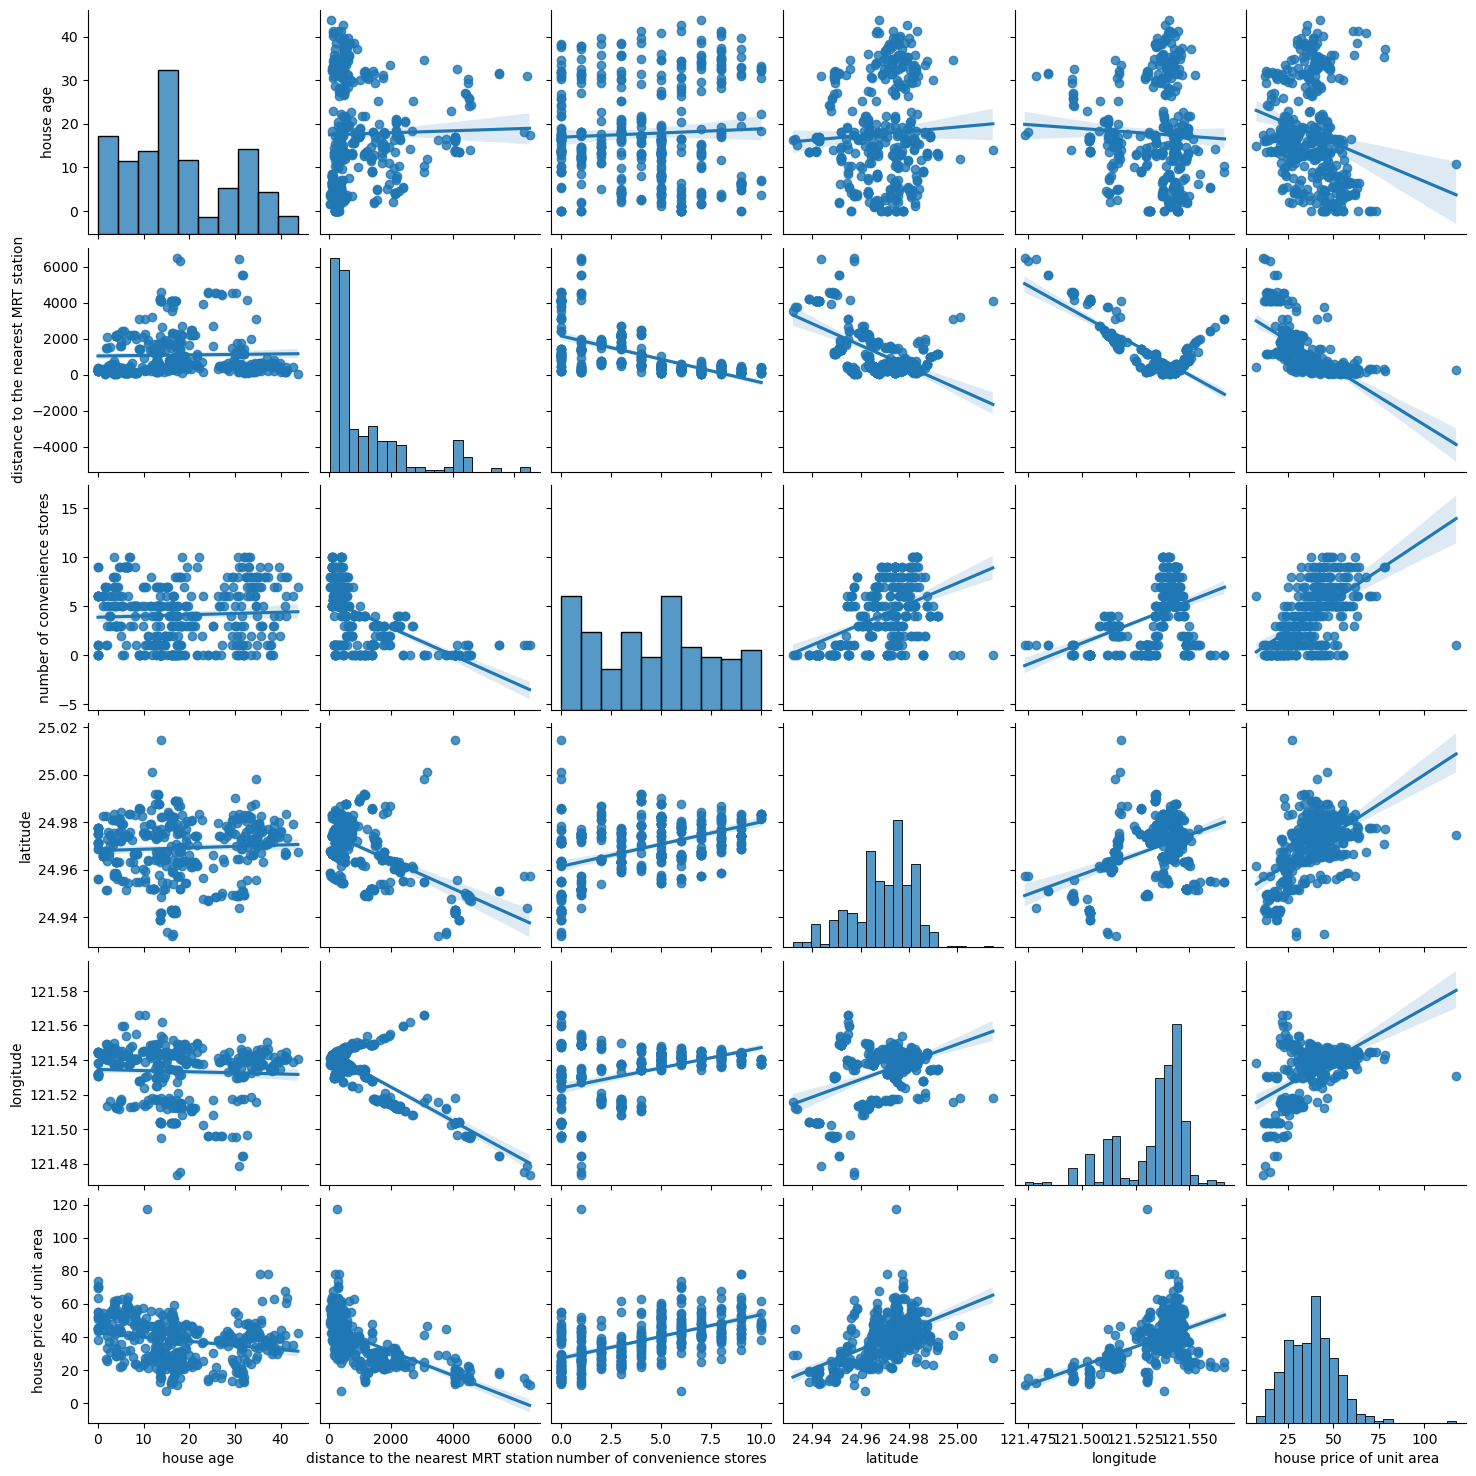

In [381]:
%pip install seaborn
import seaborn as sb
import matplotlib.pyplot as plt
sb.pairplot(dataz, kind = "reg")
plt.show()

In [ ]:
#For the simple linear regression model, let's define the target variable as 
#house price of unit area and the explanatory variable as house age.

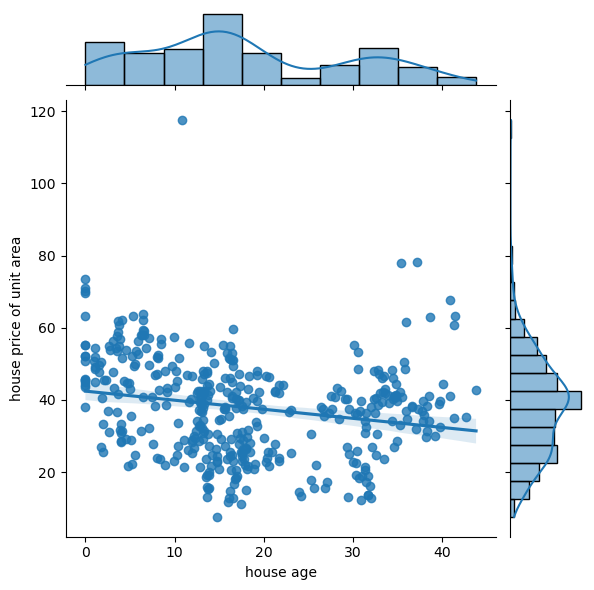

In [382]:
sb.jointplot(x = "house age", y = "house price of unit area", data = dataz, kind = "reg")

In [ ]:
#We can say that the graph shows that the price of unit area tends to decrease as the age of the house increases.

In [383]:
y = dataz[["house price of unit area"]]
x = dataz[["house age"]]

In [ ]:
#statsmodels library

In [384]:

import statsmodels.api as sm

In [385]:
x = sm.add_constant(x)
x.head()

,const,house age
0,1.0,32.0
1,1.0,19.5
2,1.0,13.3
3,1.0,13.3
4,1.0,5.0


In [386]:
mod1 = sm.OLS(y,x).fit()

In [387]:
mod1.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                               OLS Regression Results                               
====================================================================================
Dep. Variable:     house price of unit area   R-squared:                       0.044
Model:                                  OLS   Adj. R-squared:                  0.042
Method:                       Least Squares   F-statistic:                     19.11
Date:                      Thu, 06 Nov 2025   Prob (F-statistic):           1.56e-05
Time:                              21:54:18   Log-Likelihood:                -1658.3
No. Observations:                       414   AIC:                             3321.
Df Residuals:                           412   BIC:                             3329.
Df Model:                                 1                                         
Covariance Type:                  nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         42.4347      1.211     35.042      0.000      40.054      44.815
house age     -0.2515      0.058     -4.372      0.000      -0.365      -0.138
==============================================================================
Omnibus:                       48.404   Durbin-Watson:                   1.957
Prob(Omnibus):                  0.000   Jarque-Bera (JB):              119.054
Skew:                           0.589   Prob(JB):                     1.40e-26
Kurtosis:                       5.348   Cond. No.                         39.0
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [ ]:
#Comments we can make based on these values:
#The R-squared value is 0.044. This indicates that the explanatory variable explains 4.4% of the target variable. This is a very low percentage.
#The const here represents the intercept, and its value is 42.4347. This corresponds to the predicted price when the building age is 0
#The house age value came out as -0.2515. So we can say that every 1 year increase in age reduces the price per unit area by 0.25 units.

In [388]:
dataz.columns = dataz.columns.str.replace(' ', '_')

In [389]:
import statsmodels.formula.api as smf

In [390]:
from sklearn.linear_model import LinearRegression

In [391]:
model = LinearRegression().fit(x,y)

In [ ]:
#MSE and R-squared calculation

In [392]:
from sklearn.metrics import mean_squared_error, r2_score

In [ ]:
#Since the simple linear model we built with a single variable didn't provide us with much information, let's move forward by building a new model.

In [324]:
#MULTIPLE LINEAR REGRESSION MODEL

In [393]:
y=dataz["house_price_of_unit_area"]
x = dataz.drop("house_price_of_unit_area", axis = 1)

In [1825]:
#Split the dataset into a training set and a test set.

In [394]:
from sklearn.model_selection import train_test_split

In [395]:
x_train, x_test, y_train, y_test = train_test_split(x,
            y,test_size = 83, random_state = 42)

In [396]:
print("Training set size:", x_train.shape[0])  

Training set size: 331


In [397]:
print("Test set size:", x_test.shape[0])

Test set size: 83


In [398]:
model = LinearRegression().fit(x,y)

In [1837]:
#with the statsmodels library

In [399]:
x_train = sm.add_constant(x_train)  

In [400]:
x_test= sm.add_constant(x_test)

In [401]:
model = sm.OLS(y_train, x_train).fit()
model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                               OLS Regression Results                               
====================================================================================
Dep. Variable:     house_price_of_unit_area   R-squared:                       0.546
Model:                                  OLS   Adj. R-squared:                  0.539
Method:                       Least Squares   F-statistic:                     78.11
Date:                      Thu, 06 Nov 2025   Prob (F-statistic):           1.29e-53
Time:                              21:55:26   Log-Likelihood:                -1205.8
No. Observations:                       331   AIC:                             2424.
Df Residuals:                           325   BIC:                             2446.
Df Model:                                 5                                         
Covariance Type:                  nonrobust                                         
=======================================================================================================
                                          coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------------------------
const                               -2946.6589   7143.452     -0.412      0.680    -1.7e+04    1.11e+04
house_age                              -0.2706      0.046     -5.931      0.000      -0.360      -0.181
distance_to_the_nearest_MRT_station    -0.0046      0.001     -5.377      0.000      -0.006      -0.003
number_of_convenience_stores            1.1051      0.222      4.972      0.000       0.668       1.542
latitude                              236.0928     50.969      4.632      0.000     135.822     336.364
longitude                             -23.9037     56.747     -0.421      0.674    -135.541      87.734
==============================================================================
Omnibus:                      204.952   Durbin-Watson:                   1.946
Prob(Omnibus):                  0.000   Jarque-Bera (JB):             3182.094
Skew:                           2.252   Prob(JB):                         0.00
Kurtosis:                      17.506   Cond. No.                     2.25e+07
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 2.25e+07. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

In [1845]:
#Here, the value of the constant variable is both negative and very small; therefore, there is an issue with the model.
#The p-value of the longitude variable is greater than 0.05, so it is meaningless. 
#Therefore, let's remove the longitude variable from our model.

In [402]:
x_train = x_train.drop('longitude', axis=1)

In [403]:
x_test = x_test.drop('longitude', axis=1)

In [404]:
model = sm.OLS(y_train, x_train).fit()

In [405]:
model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                               OLS Regression Results                               
====================================================================================
Dep. Variable:     house_price_of_unit_area   R-squared:                       0.546
Model:                                  OLS   Adj. R-squared:                  0.540
Method:                       Least Squares   F-statistic:                     97.83
Date:                      Thu, 06 Nov 2025   Prob (F-statistic):           1.34e-54
Time:                              21:55:32   Log-Likelihood:                -1205.9
No. Observations:                       331   AIC:                             2422.
Df Residuals:                           326   BIC:                             2441.
Df Model:                                 4                                         
Covariance Type:                  nonrobust                                         
=======================================================================================================
                                          coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------------------------
const                               -5908.1020   1264.206     -4.673      0.000   -8395.133   -3421.071
house_age                              -0.2697      0.046     -5.925      0.000      -0.359      -0.180
distance_to_the_nearest_MRT_station    -0.0043      0.001     -7.282      0.000      -0.005      -0.003
number_of_convenience_stores            1.1118      0.221      5.021      0.000       0.676       1.547
latitude                              238.3364     50.626      4.708      0.000     138.742     337.931
==============================================================================
Omnibus:                      206.813   Durbin-Watson:                   1.946
Prob(Omnibus):                  0.000   Jarque-Bera (JB):             3258.540
Skew:                           2.276   Prob(JB):                         0.00
Kurtosis:                      17.682   Cond. No.                     3.99e+06
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 3.99e+06. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

In [1855]:
#Since the constant is still negative and small, we are also removing the latitude variable (because its error is high).

In [406]:
x_train = x_train.drop('latitude', axis=1)

In [407]:
x_test = x_test.drop('latitude', axis=1)

In [408]:
model = sm.OLS(y_train, x_train).fit()

In [409]:
model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                               OLS Regression Results                               
====================================================================================
Dep. Variable:     house_price_of_unit_area   R-squared:                       0.515
Model:                                  OLS   Adj. R-squared:                  0.510
Method:                       Least Squares   F-statistic:                     115.6
Date:                      Thu, 06 Nov 2025   Prob (F-statistic):           4.88e-51
Time:                              21:55:37   Log-Likelihood:                -1216.7
No. Observations:                       331   AIC:                             2441.
Df Residuals:                           327   BIC:                             2457.
Df Model:                                 3                                         
Covariance Type:                  nonrobust                                         
=======================================================================================================
                                          coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------------------------
const                                  43.5149      1.620     26.865      0.000      40.328      46.701
house_age                              -0.2584      0.047     -5.509      0.000      -0.351      -0.166
distance_to_the_nearest_MRT_station    -0.0055      0.001    -10.016      0.000      -0.007      -0.004
number_of_convenience_stores            1.2473      0.227      5.506      0.000       0.802       1.693
==============================================================================
Omnibus:                      190.006   Durbin-Watson:                   1.968
Prob(Omnibus):                  0.000   Jarque-Bera (JB):             2634.268
Skew:                           2.065   Prob(JB):                         0.00
Kurtosis:                      16.189   Cond. No.                     4.97e+03
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 4.97e+03. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

In [ ]:
#The R-squared value is 0.515, meaning that the explanatory variables explain 51% of the variation in the target variable.
#The p-value is 4.88e-51, which is smaller than 0.05, indicating that the model is statistically significant.
#When the other variables are not included, each one-unit increase raises the house price by 43.5149 unit.
#As the house age increases, the price per unit area decreases by 0.26 units, holding other variables constant. 
#Each one-unit increase in distance to the metro station reduces the price by 0.0055 units, holding other variables constant.
#As the number of nearby markets increases, the price increases by 1.2 units.  

In [410]:
model = LinearRegression().fit(x_train, y_train)

In [411]:
model.intercept_

43.514880144043865

In [412]:
model.coef_

array([ 0.        , -0.25840543, -0.00549834,  1.24734248])

In [413]:
fit = model.predict(x_test)

In [414]:
print("Training data columns:", x_train.columns.tolist())

Training data columns: ['const', 'house_age', 'distance_to_the_nearest_MRT_station', 'number_of_convenience_stores']


In [415]:
print("Test data columns:", x_test.columns.tolist())

Test data columns: ['const', 'house_age', 'distance_to_the_nearest_MRT_station', 'number_of_convenience_stores']


In [416]:
print("Train size:", x_train.shape[0], ", Test size:", x_test.shape[0])

Train size: 331 , Test size: 83


In [417]:
print("y_train size:", len(y_train), ", y_test size:", len(y_test))

y_train size: 331 , y_test size: 83


In [1349]:
#Prediction on the test set

In [418]:
pred = model.predict(x_test)

In [419]:
mean_squared_error(y_test, pred)

58.88825128983572

In [ ]:
#Lower the MSE (mean squared error) value, better the model's prediction performance will be.

In [420]:
r2_score(y_test, pred)

0.6489726933106558

In [ ]:
#Higher the R-squared value (r2_score), better the model's prediction performance will be.

In [360]:
#Calculation of the MAPE value

In [421]:
from sklearn.metrics import mean_absolute_percentage_error

In [422]:
mean_absolute_percentage_error(y_test, pred)

0.18889494293295844

In [ ]:
#The lower the MAPE value, the better the model's prediction performance will be.

In [368]:
# ALTERNATIVE LINEAR REGRESSION MODELS

In [370]:
# Principal Component Regression - PCR
# Principal Component Analysis - PCA

In [ ]:
#In the principal component regression (PCR) model, dimensionality reduction is applied to the variables, 
#and a model is built using the resulting components to obtain y predictions. 
#PCR is used as a solution to multicollinearity issues, especially in datasets with a large number of features

In [423]:
import matplotlib.pyplot as mp

In [424]:
from sklearn.preprocessing import scale   
from sklearn.decomposition import PCA      
from sklearn import model_selection

In [376]:
# k-fold cross-validation

In [425]:
from sklearn.model_selection import KFold

In [426]:
cv = KFold(n_splits=5, shuffle=True, random_state=42)

In [427]:
from sklearn.model_selection import train_test_split

In [428]:
x_train, x_test , y_train, y_test= train_test_split(x,y,test_size=83, random_state=42)

In [61]:
#Here, we split the dataset into training and test sets by setting the random_state value to 42 and the test set size to 83.

In [429]:
pca = PCA()

In [430]:
x_train_scaled = pca.fit_transform(scale(x_train))

In [431]:
from sklearn.linear_model import LinearRegression

In [432]:
regr = LinearRegression()
mse = []

In [396]:
# Calculating MSE values with K-fold cross-validation

In [433]:
for i in np.arange(1,10):
    score = -1*model_selection.cross_val_score(regr, x_train_scaled[:,:i], y_train, cv=cv, scoring="neg_mean_squared_error").mean()
    mse.append(score)

[99.4868053931142, 93.32574318831374, 90.02552854183219, 90.58542790126862, 89.57753408379774, 89.57753408379774, 89.57753408379774, 89.57753408379774, 89.57753408379774]


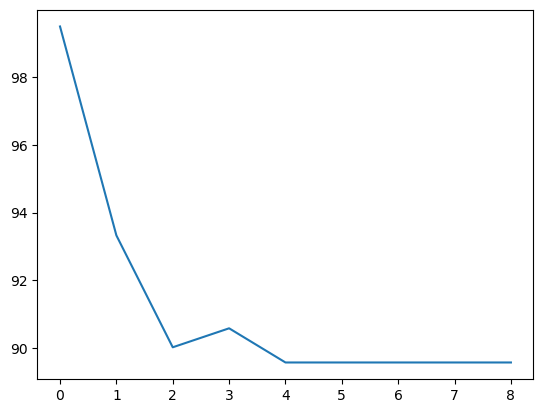

In [434]:
print(mse)
mp.plot(mse)

In [435]:
model = LinearRegression()
pcreg = model.fit(x_train_scaled, y_train)

In [436]:
pcreg.intercept_


38.39154078549849

In [437]:
pcreg.coef_

array([-5.82939753, -2.51193129,  2.41461807, -1.29337831, -3.41073915])

In [438]:
yhat = pcreg.predict(x_train_scaled)

In [410]:
# Making Predictions

In [439]:
x_test_scaled = pca.fit_transform(scale(x_test))
predict_y = pcreg.predict(x_test_scaled)

In [440]:
from sklearn.metrics import r2_score, mean_squared_error

In [441]:
r2_score(y_train, yhat)

0.5457883393347673

In [442]:
r2_score(y_test, predict_y)


0.6327389133552106

In [443]:
y_test[1:10]


350    42.3
373    52.2
399    37.3
369    22.8
72     36.3
262    53.0
140    51.4
93     16.1
70     59.0
Name: house_price_of_unit_area, dtype: float64

In [444]:
predict_y[1:10]

array([44.16309768, 40.88952057, 39.05804002, 31.74188247, 46.59668204,
       45.53817844, 45.48702752, 29.19172438, 54.0882054 ])

In [ ]:
#The R-squared value is 0.63 on the test set and 0.54 on the training set. 
#These values are quite low, and since the model's explanatory power should be higher, 
#this method is not very suitable for the data.

In [424]:
#  PARTIAL LEAST SQUARES REGRESSION (PLSR)

In [ ]:
#PLS regression refers to the process of reducing variables to a smaller number of components 
#that do not suffer from multicollinearity and establishing a regression model.

In [445]:
from sklearn.cross_decomposition import PLSRegression

In [446]:
pls_model = PLSRegression().fit(x_train,y_train)
pls_model.coef_

array([[-3.34592235, -3.66118749,  3.34028774,  3.18281112,  1.47536925]])

In [447]:
yhat_pls = pls_model.predict(x_train)
mean_squared_error(y_train, yhat_pls)

86.8274252476453

In [2099]:
#In the above model, the default number of components specified within the PLS regression function is used. To change this:

In [448]:
pls_model1 = PLSRegression(n_components=2).fit(x_train, y_train)   
yhat_pls1 = pls_model1.predict(x_train)

In [ ]:
#n_components = 2 is taken, meaning we are using 2 score variables. 
#Since the section with the sudden drop in the graph occurs at 2, n_components = 2 is taken

In [449]:
mean_squared_error(y_train,yhat_pls1)

86.8274252476453

In [ ]:
#The MSE is quite high. However, for the regression method to be appropriate for the dataset, the MSE should be low.

In [2105]:
#Determining the Optimal Number of Parameters (Components)

In [450]:
from sklearn.model_selection import cross_val_predict

In [451]:
def optimum_pls(x,y,ncomp):
    model= PLSRegression(n_components=ncomp)
    cv.step = cross_val_predict(model, x,y,cv=10)
    mse= mean_squared_error(y,cv.step)
    rsq = r2_score(y, cv.step)
    return(cv.step,rsq,mse)

In [2111]:
#Calculating Metrics for 6 Components

In [452]:
r2 = []
mse_sonuc= []

In [453]:
for i in np.arange(1,6 ):
    cv.step, rsq,mse= optimum_pls(x_train,y_train,i)
    r2.append(rsq)
    mse_sonuc.append(mse)

In [2117]:
#Results on the Test Set

In [454]:
model3= PLSRegression(n_components=2).fit(x_train, y_train)
ypred3 = model3.predict(x_test)

In [455]:
model7= PLSRegression(n_components=4).fit(x_train, y_train)
ypred7 = model7.predict(x_test)

In [456]:
mean_squared_error(y_test, ypred3)

54.164464758318516

In [457]:
mean_squared_error(y_test, ypred7)

54.4913760069634

In [458]:
r2_score(y_test,ypred3)

0.6771307388836628

In [459]:
r2_score(y_test,ypred7)

0.6751820517920142

In [ ]:
#Looking at the graph, we can estimate that the n_components value should be 2 or 4.
#We created two separate models using both of them. Next, let's examine the R-squared (r2_score) and 
#MSE (mean_squared_error) values for both models. If we compare the values of these two models, 
#the R-squared values and MSE values are nearly identical.

In [ ]:
#However, both models show low R-squared values and high MSE values, indicating that this regression method is not suitable for the dataset.

In [ ]:
### RIDGE REGRESSION 

In [ ]:
#This method is typically used when there are multiple explanatory variables. 
#Ridge Regression is applied if overfitting occurs.

In [460]:
from sklearn.linear_model import Ridge

In [461]:
ridge_model1 = Ridge(alpha=0.35).fit(x_train, y_train)

In [462]:
ridge_model1.coef_

array([-2.59540256e-01, -5.42905842e-03,  1.23398367e+00,  2.09965218e+01,
       -3.54291923e+00])

In [463]:
yhat_ridge = ridge_model1.predict(x_train)

In [464]:
mean_squared_error(y_train, yhat_ridge)

90.2845283887544

In [465]:
r2_score(y_train, yhat_ridge)

0.5199942197610827

In [466]:
yhat_ridge1 = ridge_model1.predict(x_test)

In [467]:
mean_squared_error(y_test, yhat_ridge1)

58.13651049102215

In [468]:
r2_score(y_test, yhat_ridge1)

0.6534537492455188

In [ ]:
#Looking at the results, we can see that the MSE and R-squared values differ significantly between the training and test sets.

In [ ]:
#Selecting the Optimum Parameter

In [469]:
r2 = []
mse = []

In [470]:
alpha_cand = np.array([0, 0.0001, 0.001, 0.01, 0.1, 0.2, 0.5, 1, 5, 10])

In [471]:
for i in alpha_cand:
    model_i = Ridge(alpha=i).fit(x_train, y_train)
    yhat_i = model_i.predict(x_train)
    r2.append(r2_score(y_train, yhat_i))
    mse.append(mean_squared_error(y_train, yhat_i))

In [472]:
r2

[0.5457883393347678,
 0.5457880764806364,
 0.5457633906880421,
 0.5442088022600193,
 0.5285856518256834,
 0.5231488177815264,
 0.5185443574048123,
 0.5166922274968488,
 0.5150701702419931,
 0.5148568902008808]

In [473]:
mse

[85.4328994776314,
 85.43294891799701,
 85.43759208112971,
 85.72999539967473,
 88.66856161487428,
 89.69117846203041,
 90.5572337278429,
 90.90560177285259,
 91.21069533693701,
 91.25081128703447]

In [474]:
ridge_model = Ridge(alpha=0.005).fit(x_train, y_train)

In [475]:
ridge_model.coef_

array([-2.69123296e-01, -4.69798787e-03,  1.12260004e+00,  2.05776580e+02,
       -2.31870789e+01])

In [476]:
yhat_ridge2 = ridge_model.predict(x_train)

In [477]:
mean_squared_error(y_train, yhat_ridge2)

85.5273854506681

In [478]:
r2_score(y_train, yhat_ridge2)

0.5452859961978149

In [479]:
yhat_ridge3 = ridge_model.predict(x_test)

In [480]:
mean_squared_error(y_test, yhat_ridge3)

54.6457122003875

In [481]:
r2_score(y_test, yhat_ridge3)

0.6742620683128699

In [ ]:
#Here, the MSE values are high and the R-squared values are low for both models.

In [ ]:
#There are better regression methods suitable for the dataset. We can conclude that Ridge Regression is not suitable.

In [ ]:
#### LASSO REGRESSION

In [ ]:
#It is a regression method that aims to reduce model complexity by setting regression coefficients to zero and minimizing them.

In [482]:
from sklearn.linear_model import Lasso

In [483]:
lasso_model = Lasso(alpha=0.35).fit(x_train, y_train)

In [484]:
yhat_lasso = lasso_model.predict(x_train)

In [485]:
mean_squared_error(y_train, yhat_lasso)

91.31518482452059

In [486]:
r2_score(y_train, yhat_lasso)

0.514514642524128

In [487]:
yhat_lasso1 = lasso_model.predict(x_test)

In [488]:
mean_squared_error(y_test, yhat_lasso1)

59.07621675887468

In [489]:
r2_score(y_test, yhat_lasso1)

0.6478522488942883

In [ ]:
# Lambda Optimization

In [490]:
from sklearn.linear_model import LassoCV

In [491]:
lasso_model = LassoCV(cv = 10, random_state= 42, max_iter= 100).fit(x_train, y_train)

In [492]:
lasso_model.alpha_

10.957713857750294

In [493]:
lasso_model = Lasso(alpha=0.35).fit(x_train, y_train)

In [494]:
yhat_lasso2 = lasso_model.predict(x_train)

In [495]:
mean_squared_error(y_train, yhat_lasso2)

91.31518482452059

In [496]:
r2_score(y_train, yhat_lasso)

0.514514642524128

In [497]:
yhat_lasso3 = lasso_model.predict(x_test)

In [498]:
mean_squared_error(y_test, yhat_lasso3)

59.07621675887468

In [499]:
r2_score(y_test, yhat_lasso3)

0.6478522488942883

In [ ]:
#The R-squared values are low and the MSE values are high, indicating that Lasso Regression is not a suitable method for this dataset.

In [ ]:
######## NONLINEAR REGRESSION MODELS

In [ ]:
#It is a method for finding a nonlinear model that describes the relationship between a target variable and a set of explanatory variables.

In [ ]:
## K-NEAREST NEIGHBORS REGRESSION (KNN)

In [ ]:
#It is a regression method in which predictions are made based on the similarities between observations.
#The K observations closest to the one we want to predict are identified, and the prediction is made based on their target variable values.

In [500]:
from sklearn.neighbors import KNeighborsRegressor

In [501]:
KNN_model = KNeighborsRegressor().fit(x_train, y_train)

In [502]:
KNN_model.n_neighbors

5

In [189]:
#By default, it corresponds to 5 neighbors.

In [503]:
yhat_KNN = KNN_model.predict(x_train)

In [504]:
mean_squared_error(y_train, yhat_KNN)

48.01602658610272

In [505]:
r2_score(y_train, yhat_KNN)

0.7447184947769454

In [506]:
yhat_KNN1 = KNN_model.predict(x_test)

In [507]:
mean_squared_error(y_test, yhat_KNN1)

54.839122891566284

In [508]:
r2_score(y_test, yhat_KNN1)

0.6731091654413741

In [509]:
mse = []
r2 = []

In [510]:
for i in range(1, 20):
    Kmodel_i = KNeighborsRegressor(n_neighbors=i).fit(x_train, y_train)
    Ypred_i = Kmodel_i.predict(x_test)
    mse.append(mean_squared_error(y_test, Ypred_i))
    r2.append(r2_score(y_test, Ypred_i))

In [511]:
mse

[66.58975903614457,
 49.602590361445785,
 50.3022891566265,
 51.37427710843374,
 54.839122891566284,
 55.245408299866135,
 55.24456601917876,
 55.97151543674698,
 53.77082849918192,
 52.08230120481927,
 49.62781240665138,
 48.42733684738954,
 47.62732088115776,
 46.069712933366105,
 45.937225702811226,
 46.754847044427706,
 46.94438237378579,
 48.735502751747724,
 46.49263358141708]

In [512]:
r2

[0.6030647326831928,
 0.7043236415071052,
 0.7001528030429571,
 0.6937627840615093,
 0.6731091654413741,
 0.6706873364772103,
 0.6706923572328737,
 0.6663590803812243,
 0.6794771674637867,
 0.6895423192628158,
 0.7041732952766808,
 0.7113292167565024,
 0.7160980364070069,
 0.7253827903403538,
 0.7261725342144503,
 0.7212987705832844,
 0.7201689683777546,
 0.7094922688925231,
 0.7228618002824563]

In [ ]:
#Grid Search Algorithm for KNN

In [513]:
from sklearn.model_selection import GridSearchCV

In [514]:
KNN_arg = KNeighborsRegressor()

In [515]:
k_param = {"n_neighbors": [2,3,4,5,6,7,8,9,10,15,20,30,35,40]}

In [516]:
KNN_model = GridSearchCV(KNN_arg, k_param, cv = 5)

In [517]:
KNN_model.fit(x_train, y_train)

GridSearchCV(cv=5, estimator=KNeighborsRegressor(),
             param_grid={'n_neighbors': [2, 3, 4, 5, 6, 7, 8, 9, 10, 15, 20, 30,
                                         35, 40]})

In [518]:
KNN_model.best_params_

{'n_neighbors': 2}

In [ ]:
#Compared to the previous regression methods, the R-squared value is slightly higher and the MSE value is slightly lower.
#However, we will determine the most appropriate regression method by comparing it with the other regression models.

In [ ]:
#SUPPORT VECTOR MACHINE (SVM)

In [519]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score

In [ ]:
#SUPPORT VECTOR REGRESSION (SVR)

In [ ]:
#Linear SVR

In [ ]:
#It is a type of Support Vector Machine (SVM) designed to predict continuous numerical values.

In [520]:
from sklearn.svm import SVR

In [521]:
model_svr = SVR(kernel = "linear").fit(x_train, y_train)

In [522]:
y_pred = model_svr.predict(x_test)

In [523]:
mean_squared_error(y_test, y_pred)

60.72584171056203

In [524]:
r2_score(y_test, y_pred)

0.6380189902874345

In [ ]:
#The R-squared value is 0.63, and the MSE value is 60.72. The MSE is high, and the R-squared is low.
#It doesn’t seem to be a regression method suitable for the dataset.

In [2610]:
# Nonlinear SVR

In [525]:
model_svr2 = SVR(kernel = "rbf").fit(x_train, y_train)

In [526]:
y_pred2 = model_svr2.predict(x_test)

In [527]:
mean_squared_error(y_test, y_pred2)

64.32659316483725

In [528]:
r2_score(y_test, y_pred2)

0.616555250791571

In [ ]:
#The R-squared value is low again, and the MSE is high. It does not appear to be a very suitable regression method for the dataset.

In [ ]:
#Parameter Optimization

In [531]:
from sklearn.model_selection import GridSearchCV

In [532]:
params_svr = {"C":np.arange(0.1,2,0.4)}

In [533]:
gs_svr_model = GridSearchCV(model_svr2, params_svr, cv = 10)

In [534]:
model_GS =gs_svr_model.fit(x_train, y_train)

In [535]:
opt_c = pd.Series(model_GS.best_params_)[0]

C:\Users\betul\AppData\Local\Temp\ipykernel_20384\2624740421.py:1: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  opt_c = pd.Series(model_GS.best_params_)[0]


In [536]:
model_optimal = SVR(kernel ="rbf",C=1.7).fit(x_train, y_train)

In [537]:
y_pred_optim = model_optimal.predict(x_test)

In [538]:
mean_squared_error(y_test, y_pred_optim)

60.58210939961067

In [539]:
r2_score(y_test, y_pred_optim)

0.638875765024201

In [ ]:
#With parameter optimization, the R-squared and MSE values did not change significantly. There must be models that perform better.
#SVR is not a suitable regression method for this dataset.

In [ ]:
#### ARTIFICIAL NEURAL NETWORKS (ANN-MLP)

In [ ]:
#It is a machine learning model inspired by the structure and function of the interconnected neuron network in the human brain.

In [ ]:
# Standardization is required for ANN.

In [570]:
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPRegressor

In [571]:
scl = StandardScaler().fit(x_train)

In [572]:
x_train_scl = scl.transform(x_train)

In [573]:
x_test_scl = scl.transform(x_test)

In [574]:
ann_model =MLPRegressor().fit(x_train_scl,y_train)

C:\Users\betul\Downloads\jupyter\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(


In [575]:
ann_model.n_layers_

3

In [576]:
ann_model.hidden_layer_sizes

(100,)

In [577]:
ann_pred = ann_model.predict(x_test_scl)

In [578]:
mean_squared_error(y_test,ann_pred)

165.4082549820659

In [579]:
r2_score(y_test,ann_pred)

0.01401700714857701

In [ ]:
#The values are very poor without optimization. The R-squared value is 0.014, which is quite low.
#The MSE value is very high at 165.40. Let’s look at how it is with optimization:

In [ ]:
#Parameter Optimization

In [600]:
params_ann = {'alpha':[0.1,0.01,0.02,0.005],
              'hidden_layer_sizes':[(20,20),(100,50,150),(300,200,100)],
              'activation':["relu","logistic"]}

In [601]:
gs_ann_model = GridSearchCV(ann_model, params_ann, cv = 5).fit(x_train_scl, y_train)

C:\Users\betul\Downloads\jupyter\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(
C:\Users\betul\Downloads\jupyter\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(
C:\Users\betul\Downloads\jupyter\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(
C:\Users\betul\Downloads\jupyter\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(
C:\Users\betul\Downloads\jupyter\Lib\sit

In [602]:
gs_ann_model.best_params_

{'activation': 'relu', 'alpha': 0.02, 'hidden_layer_sizes': (300, 200, 100)}

In [603]:
best_ann = MLPRegressor(alpha=0.02, activation="relu", hidden_layer_sizes=(300, 200, 100)).fit(x_train_scl, y_train)

C:\Users\betul\Downloads\jupyter\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(


In [604]:
best_pred = best_ann.predict(x_test_scl)

In [605]:
mean_squared_error(y_test, best_pred)

36.80332487740305

In [606]:
r2_score(y_test, best_pred)

0.7806188547636906

In [220]:
#The R-squared value is 0.78, and the MSE value is 36.80. Compared to the other methods, this has been the best-performing regression method so far.

In [ ]:
####### Classification and Regression Trees (CART)

In [ ]:
#It forms the basis of Random Forest. The purpose of CART is to convert complex structures within the dataset into simple decision rules.

In [896]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error,r2_score
from sklearn.model_selection import GridSearchCV

In [897]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size = 30)
from sklearn.tree import DecisionTreeRegressor

In [898]:
model2 = DecisionTreeRegressor().fit(x_train, y_train)
preds = model2.predict(x_test)

In [899]:
mean_squared_error(y_test, preds)

28.09289814814815

In [900]:
r2_score(y_test, preds)

0.8138338225879433

In [ ]:
#Model Optimization

In [901]:
cart_pars = {"min_samples_split": range(2,100),
             "max_leaf_nodes": range(2,10)}

In [902]:
cart_grid = GridSearchCV(model2, cart_pars, cv = 10).fit(x_train, y_train)

In [903]:
cart_grid.best_params_

{'max_leaf_nodes': 7, 'min_samples_split': 81}

In [904]:
model3 = DecisionTreeRegressor(max_leaf_nodes = 7,
                              min_samples_split = 81).fit(x_train, y_train)

In [905]:
preds = model3.predict(x_test)

In [906]:
mean_squared_error(y_test, preds)

38.975300162691674

In [907]:
r2_score(y_test, preds)

0.7417182589524279

In [ ]:
#Without model optimization, the R-squared value is 0.81 and the MSE is 28.09. 
#With model optimization, the R-squared value is 0.74 and the MSE is 38.97.
#For this method, the values without model optimization are better.
#The R-squared value is high and the MSE value is low.
#This regression method is suitable for the dataset.

In [ ]:
######BAGGING (Bootsrap Aggregation)

In [ ]:
#Bagging is an ensemble method that can be used for both regression and classification.

In [832]:
from sklearn.ensemble import BaggingRegressor

In [833]:
model4 =BaggingRegressor(bootstrap_features=(True)).fit(x_train, y_train)

In [834]:
preds = model4.predict(x_test)

In [835]:
mean_squared_error(y_test,preds)

28.02353800211058

In [836]:
r2_score(y_test,preds)

0.8178850822038428

In [ ]:
#Model Optimization

In [837]:
params ={"n_estimators": range(2,40)}
bag_cv = GridSearchCV(model4, params, cv = 10).fit(x_train, y_train)

In [838]:
bag_cv.best_params_

{'n_estimators': 36}

In [839]:
model5 = BaggingRegressor(bootstrap_features=(True), n_estimators = 36).fit(x_train, y_train)

In [840]:
preds = model5.predict(x_test)

In [841]:
mean_squared_error(y_test, preds)

25.467741090381075

In [842]:
r2_score(y_test,preds)

0.8344942892371674

In [ ]:
#Without model optimization, the R-squared value is 0.81 and the MSE was 28.02. 
#With model optimization, the R-squared value increased to 0.83 and the MSE decreased to 25.46. 
#Since the R-squared value is very high and the MSE is low, this regression model appears to be very suitable for the dataset.

In [ ]:
######RANDOM FOREST REGRESSION

In [ ]:
#It is one of the most commonly used regression methods, as it produces good results even without hyperparameter tuning and 
#can be applied to both regression and classification problems.

In [809]:
from sklearn.ensemble import RandomForestRegressor

In [810]:
model6 = RandomForestRegressor().fit(x_train, y_train)

In [811]:
preds = model6.predict(x_test)

In [812]:
mean_squared_error(y_test, preds)

28.9540967573136

In [813]:
r2_score(y_test, preds)

0.811837714765958

In [ ]:
#Model Optimization

In [814]:
params = {"max_depth": range(1,5), "max_features": [2,3,5],
          "n_estimators": [100,200]}

In [815]:
rf_cv = GridSearchCV(model6, params, cv = 10).fit(x_train, y_train)

In [816]:
rf_cv.best_params_

{'max_depth': 4, 'max_features': 3, 'n_estimators': 100}

In [818]:
model7 = RandomForestRegressor(max_depth = 4, max_features = 3,
                              n_estimators = 100).fit(x_train, y_train)

In [819]:
preds = model7.predict(x_test)

In [820]:
mean_squared_error(y_test, preds)

26.367296808201235

In [821]:
r2_score(y_test, preds)

0.8286483994144211

In [ ]:
#Without model optimization, the R-squared value is 0.81 and the MSE value is 28.95. With model optimization, 
#the R-squared value is 0.82 and the MSE value is 26.36. Since the R-squared value is high and the MSE value is low, 
#this regression method also appears to be suitable for the dataset.

In [ ]:
#####GRADIENT BOOSTING REGRESSION

In [ ]:
#It is used to solve complex regression and classification problems.

In [799]:
from sklearn.ensemble import GradientBoostingRegressor

In [800]:
model8 = GradientBoostingRegressor().fit(x_train, y_train)

In [801]:
preds = model8.predict(x_test)

In [802]:
mean_squared_error(y_test, preds)

25.44402757866882

In [803]:
r2_score(y_test, preds)

0.8346483948406714

In [ ]:
#Model Optimization

In [789]:
params = {"learning_rate":[0.001,0.01,0.1], "max_depth":[3,5,10],
          "n_estimators": [100,200], "subsample": [1, 0.5, 0.75]}

In [790]:
gb_cv = GridSearchCV(model8, params, cv = 10,
                     n_jobs = -1, verbose = 2).fit(x_train, y_train)

Fitting 10 folds for each of 54 candidates, totalling 540 fits


In [791]:
preds = gb_cv.best_estimator_.predict(x_test)

In [792]:
mean_squared_error(y_test, preds)

19.77137660408174

In [793]:
r2_score(y_test, preds)

0.871512918008496

In [ ]:
#In this method, without model optimization, the R-squared values is 0.83 and the MSE value is 25.44.
#With model optimization, the R-squared value is 0.87 and the MSE value is 19.77. 
#The R-squared value is high and the MSE value is low, just as desired.
#This regression method is highly suitable for the dataset.

In [ ]:
######XGBoost REGRESSION

In [ ]:
#XGBoost is used in regression to predict the continuous value of a target variable.

In [729]:
!pip install xgboost

In [730]:
from xgboost import XGBRegressor

In [731]:
model9 = XGBRegressor().fit(x_train, y_train)

In [732]:
preds = model9.predict(x_test)

In [733]:
mean_squared_error(y_test, preds)

27.546970396776924

In [734]:
r2_score(y_test, preds)

0.8209821240642644

In [735]:
#Model Optimization

In [747]:
params = {"colsample_bytree": [0.4,0.5,0.6,0.7,0.9,1],
          "n_estimators":[100,250,500],
          "learning_rate":[0.001,0.01,0.1]}

In [748]:
xgb_cv = GridSearchCV(model9, params, cv = 10,
                      n_jobs = -1,verbose = 2).fit(x_train, y_train)

Fitting 10 folds for each of 54 candidates, totalling 540 fits


In [749]:
print(xgb_cv.best_params_)

{'colsample_bytree': 0.4, 'learning_rate': 0.01, 'n_estimators': 250}


In [750]:
model10 = XGBRegressor(colsample_bytree = 0.4, learning_rate = 0.01,
                     n_estimators = 250).fit(x_train, y_train)

In [751]:
preds = model10.predict(x_test)

In [752]:
mean_squared_error(y_test, preds)

25.37714507645488

In [753]:
r2_score(y_test, preds)

0.8350830402231273

In [ ]:
#In this method, without model optimization, the R-squared value is 0.82 and the MSE is 27.54. 
#With model optimization, the R-squared value is 0.83 and the MSE is 25.37. This regression method is also suitable for the dataset.

In [ ]:
#When all regression methods are considered, the one that achieves high R-squared and low MSE values is GRADIENT BOOSTING regression. 
#It is therefore selected as the method that most accurately explains and analyzes this dataset.

In [ ]:
#The explanatory variables in the model explain 87% of the target variable, which is a very good proportion.